In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("/content/Food_Delivery_Times.csv")

In [7]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 9


In [9]:
print(df.columns.tolist())

['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [11]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [12]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 120


In [13]:
categorical_missing = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day"
]

for col in categorical_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"].fillna(
    df["Courier_Experience_yrs"].median()
)

In [ ]:
print(df.isnull().sum())

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.592000,56.732000
std,288.819436,5.696656,7.204553,2.871198,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [17]:
for col in ["Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"]:
    print("\n", col)
    print(df[col].value_counts())



 Weather
Weather
Clear    500
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64

 Traffic_Level
Traffic_Level
Medium    420
Low       383
High      197
Name: count, dtype: int64

 Time_of_Day
Time_of_Day
Morning      338
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64

 Vehicle_Type
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64


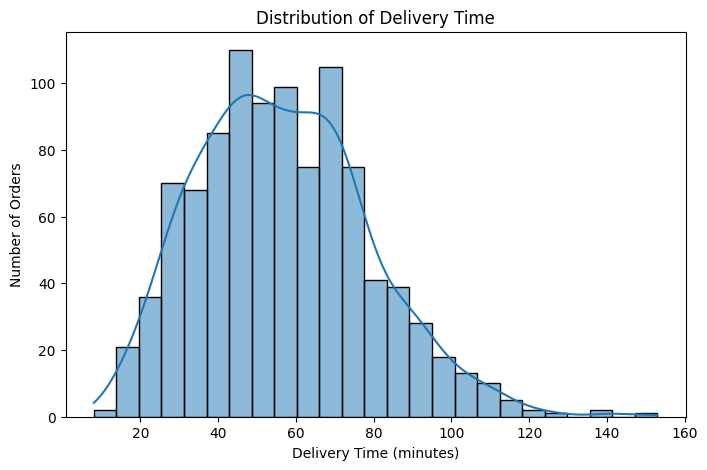

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["Delivery_Time_min"], kde=True)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")

plt.show()

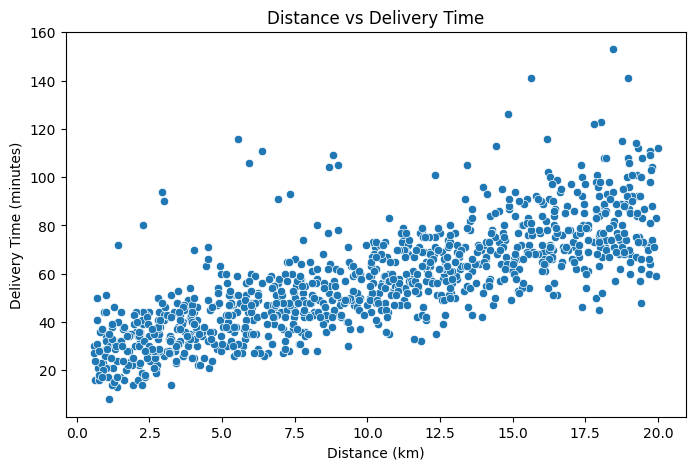

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Distance_km",
    y="Delivery_Time_min",
    data=df
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.show()

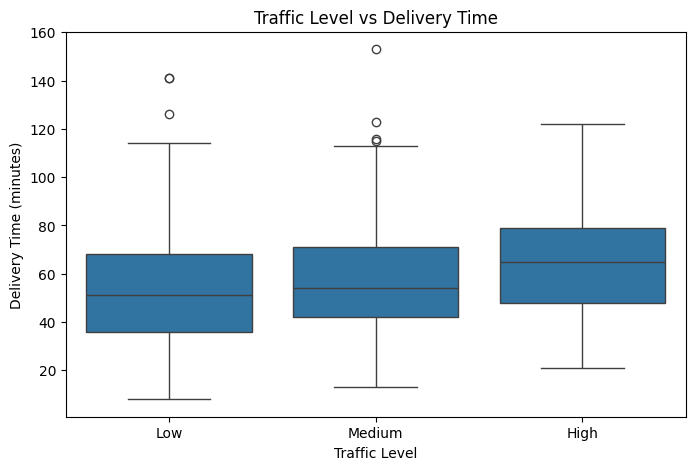

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Traffic_Level",
    y="Delivery_Time_min",
    data=df
)

plt.title("Traffic Level vs Delivery Time")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (minutes)")

plt.show()

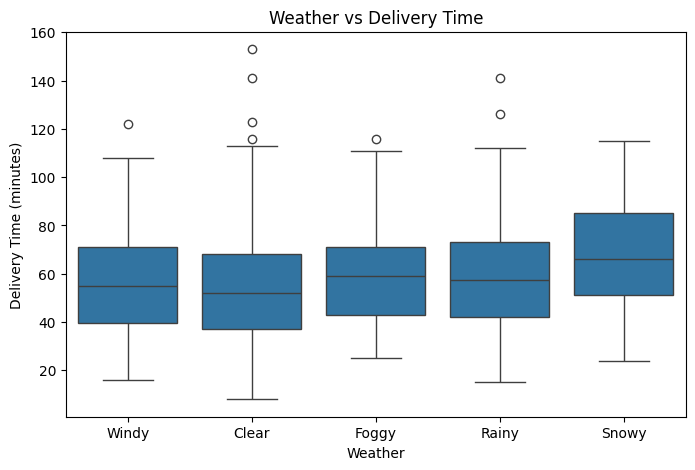

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Weather",
    y="Delivery_Time_min",
    data=df
)

plt.title("Weather vs Delivery Time")
plt.xlabel("Weather")
plt.ylabel("Delivery Time (minutes)")

plt.show()

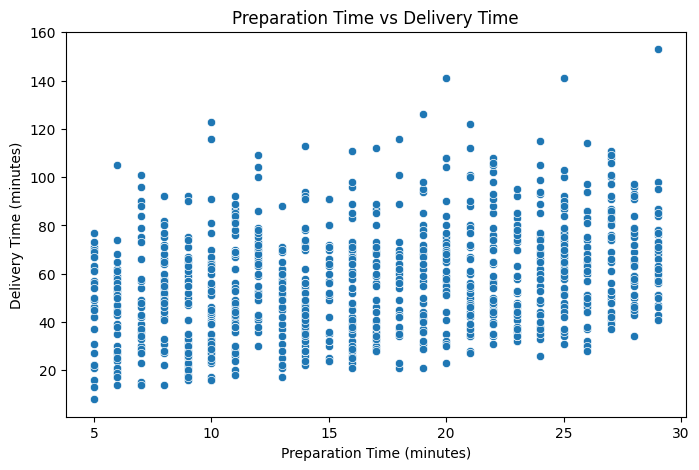

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Preparation_Time_min",
    y="Delivery_Time_min",
    data=df
)

plt.title("Preparation Time vs Delivery Time")
plt.xlabel("Preparation Time (minutes)")
plt.ylabel("Delivery Time (minutes)")

plt.show()

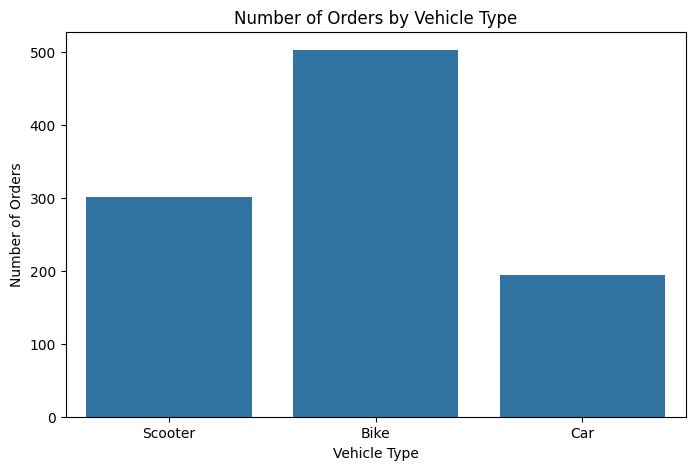

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Vehicle_Type",
    data=df
)

plt.title("Number of Orders by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Orders")

plt.show()

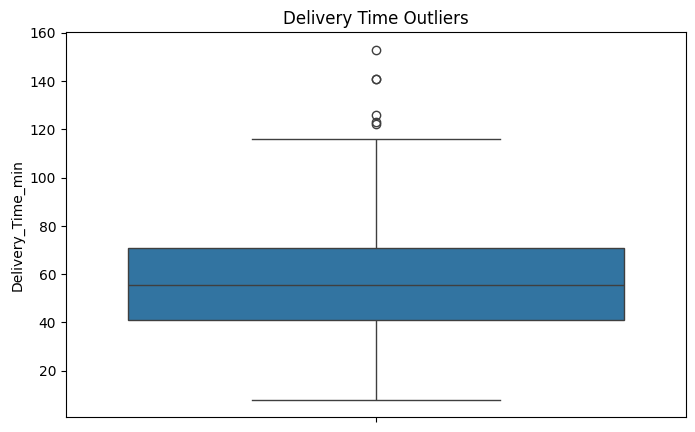

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["Delivery_Time_min"]
)

plt.title("Delivery Time Outliers")

plt.show()

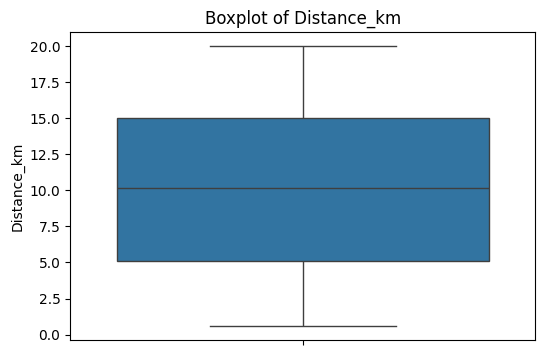

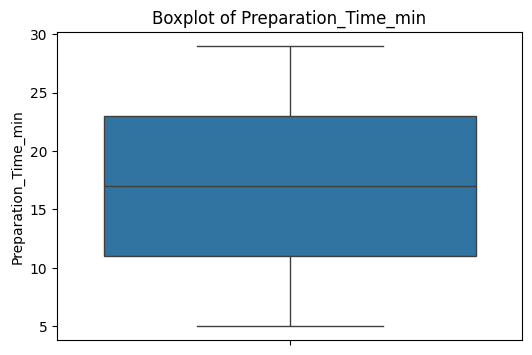

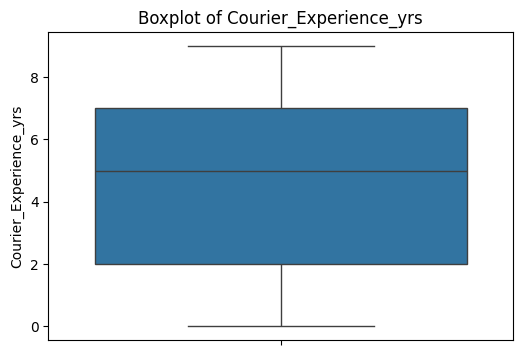

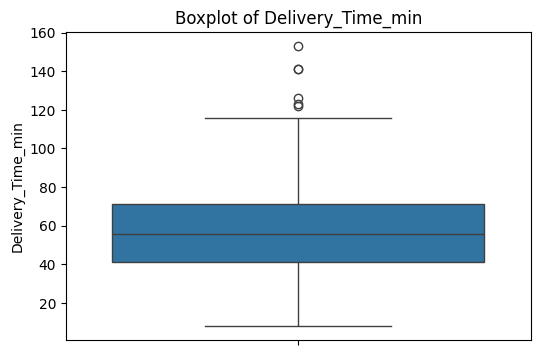

In [25]:
numeric_columns = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Delivery_Time_min"
]

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [26]:
X = df.drop("Delivery_Time_min", axis=1)
y = df["Delivery_Time_min"]

In [27]:
X = X.drop("Order_ID", axis=1)

In [28]:
print(X.columns)

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs'],
      dtype='object')


In [29]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

Categorical features:
['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']


In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 7)
Testing data: (200, 7)


In [32]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42
    )
}

In [33]:
results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

    trained_models[name] = pipeline

In [34]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE"
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.899169,77.906575,8.826470,0.826189
3,Gradient Boosting,6.431173,85.862881,9.266223,0.808439
2,Random Forest,6.868250,93.831344,9.686658,0.790661
4,Extra Trees,7.020450,101.209098,10.060273,0.774201
1,Decision Tree,11.075000,251.895000,15.871200,0.438019


In [35]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [36]:
best_model = trained_models[best_model_name]

print(
    results_df[
        results_df["Model"] == best_model_name
    ]
)

               Model       MAE        MSE     RMSE  R2 Score
0  Linear Regression  5.899169  77.906575  8.82647  0.826189


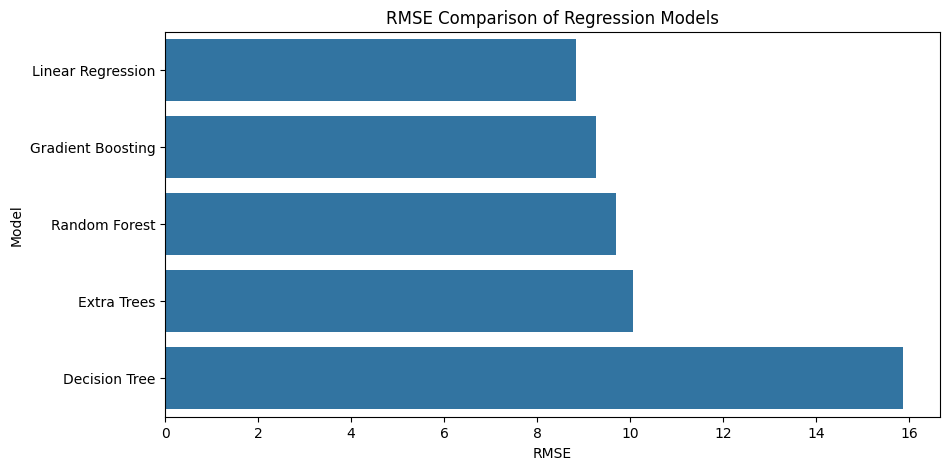

In [37]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="RMSE",
    y="Model",
    data=results_df
)

plt.title("RMSE Comparison of Regression Models")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.show()

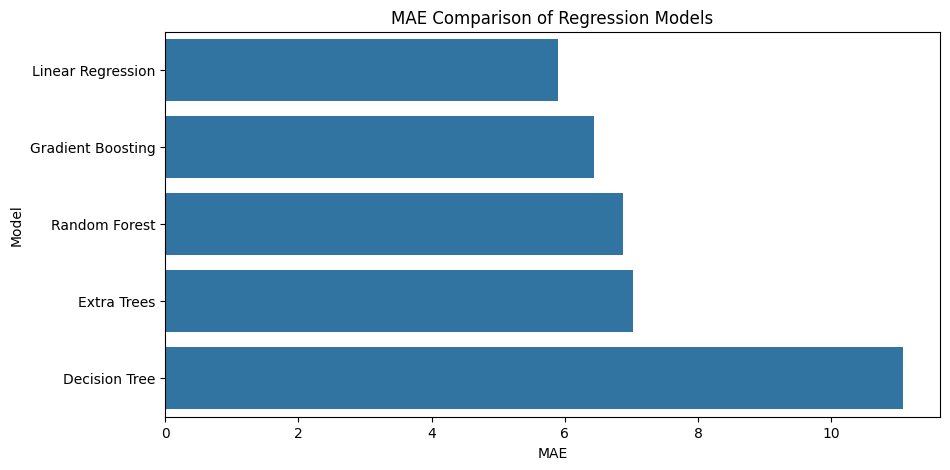

In [38]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="MAE",
    y="Model",
    data=results_df
)

plt.title("MAE Comparison of Regression Models")
plt.xlabel("MAE")
plt.ylabel("Model")

plt.show()

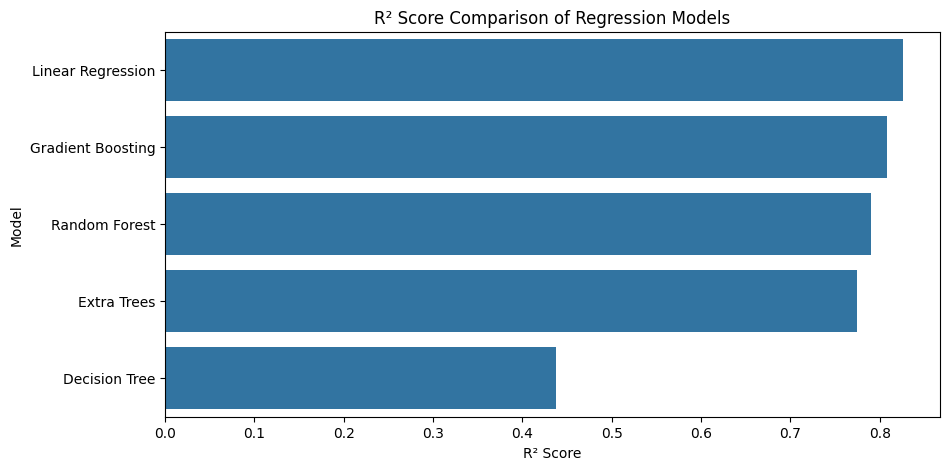

In [39]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="R2 Score",
    y="Model",
    data=results_df
)

plt.title("R² Score Comparison of Regression Models")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

In [40]:
y_pred_best = best_model.predict(X_test)

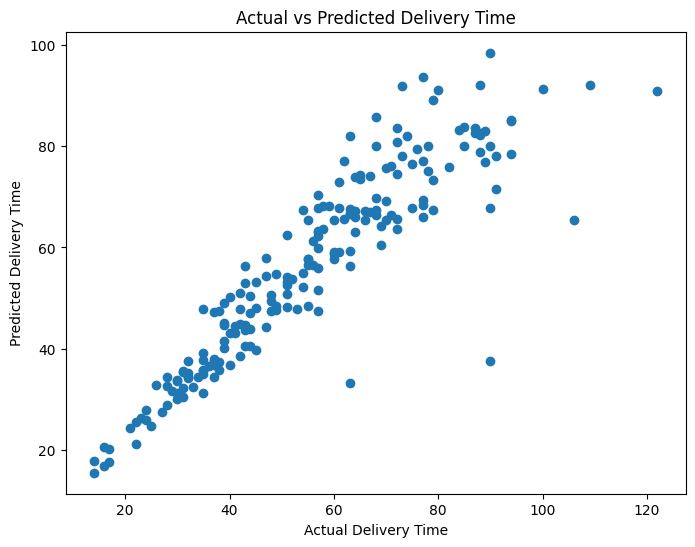

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_best
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")

plt.title("Actual vs Predicted Delivery Time")

plt.show()

In [42]:
residuals = y_test - y_pred_best

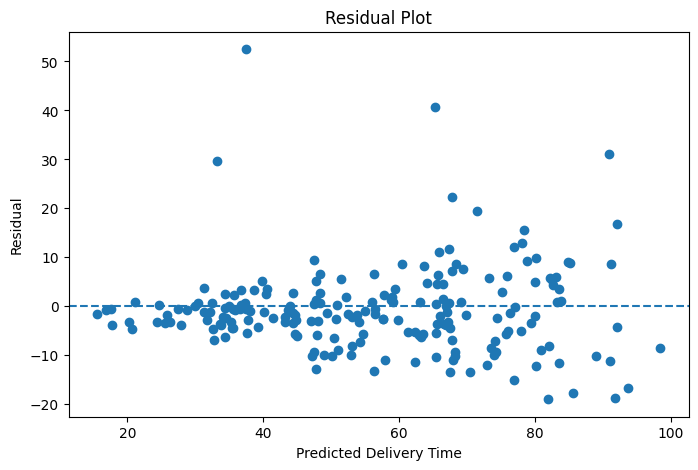

In [43]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_best,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Delivery Time")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [44]:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

In [45]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)

In [46]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [48]:
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Distance_km',
                                                                          'Preparation_Time_min',
                                                                          'Courier_Experience_yrs']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Weather',
                                                                          'Traffic_Level',
                                                                          'Time_of_Day',
                                                                          'Vehicle_Type'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='neg_root_mean_squared_error')

In [49]:
print(grid_search.best_params_)

{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [50]:
tuned_model = grid_search.best_estimator_

tuned_pred = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_pred
)

tuned_mse = mean_squared_error(
    y_test,
    tuned_pred
)

tuned_rmse = np.sqrt(tuned_mse)

tuned_r2 = r2_score(
    y_test,
    tuned_pred
)

print("Tuned Model Performance")
print("-----------------------")
print("MAE :", tuned_mae)
print("MSE :", tuned_mse)
print("RMSE:", tuned_rmse)
print("R²  :", tuned_r2)

Tuned Model Performance
-----------------------
MAE : 6.722507072664866
MSE : 92.3484488264341
RMSE: 9.609810030715181
R²  : 0.793969453028939


In [51]:
final_model = tuned_model

In [52]:
joblib.dump(
    final_model,
    "best_food_delivery_model.pkl"
)

['best_food_delivery_model.pkl']

In [53]:
import os

print(os.path.exists("best_food_delivery_model.pkl"))

True


In [54]:
new_order = pd.DataFrame({
    "Distance_km": [5.0],
    "Weather": ["Sunny"],
    "Traffic_Level": ["Medium"],
    "Time_of_Day": ["Evening"],
    "Vehicle_Type": ["Bike"],
    "Preparation_Time_min": [20],
    "Courier_Experience_yrs": [3]
})

In [55]:
prediction = final_model.predict(new_order)

print(
    "Predicted Delivery Time:",
    round(prediction[0], 2),
    "minutes"
)

Predicted Delivery Time: 43.79 minutes


In [56]:
from google.colab import files

files.download(
    "best_food_delivery_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
files.download("model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
print(df["Weather"].unique())
print(df["Traffic_Level"].unique())
print(df["Time_of_Day"].unique())
print(df["Vehicle_Type"].unique())

['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy']
['Low' 'Medium' 'High']
['Afternoon' 'Evening' 'Night' 'Morning']
['Scooter' 'Bike' 'Car']


In [59]:
import sklearn
import joblib

print("Scikit-learn:", sklearn.__version__)
print("Joblib:", joblib.__version__)

Scikit-learn: 1.6.1
Joblib: 1.6.0


In [62]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Models for cross-validation
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

cv_results = {}

for name, model in models.items():

    # Combine your existing preprocessing with the model
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_results[name] = scores

    print(name)
    print("R² scores:", scores)
    print("Mean R²:", scores.mean())
    print("Standard Deviation:", scores.std())
    print("--------------------------------")

Linear Regression
R² scores: [0.80583045 0.67756954 0.77647609 0.71491725 0.78787211]
Mean R²: 0.7525330861870382
Standard Deviation: 0.04836777299960493
--------------------------------
Decision Tree
R² scores: [0.36148245 0.45284076 0.30561481 0.48684649 0.38767678]
Mean R²: 0.398892258948219
Standard Deviation: 0.06461014068492647
--------------------------------
Random Forest
R² scores: [0.77645641 0.61681376 0.68388846 0.68003509 0.71132939]
Mean R²: 0.6937046247059329
Standard Deviation: 0.0516796084917947
--------------------------------
Extra Trees
R² scores: [0.72863771 0.6342793  0.64013023 0.64573279 0.67701154]
Mean R²: 0.6651583133255972
Standard Deviation: 0.03500686332795812
--------------------------------
Gradient Boosting
R² scores: [0.77028858 0.61033031 0.73963979 0.68297523 0.75738408]
Mean R²: 0.712123599506778
Standard Deviation: 0.058992061757946246
--------------------------------


In [63]:
cv_summary = []

for name, scores in cv_results.items():

    cv_summary.append({
        "Model": name,
        "Mean R²": scores.mean(),
        "Std R²": scores.std()
    })

cv_summary_df = pd.DataFrame(cv_summary)

cv_summary_df = cv_summary_df.sort_values(
    by="Mean R²",
    ascending=False
)

cv_summary_df

,Model,Mean R²,Std R²
0,Linear Regression,0.752533,0.048368
4,Gradient Boosting,0.712124,0.058992
2,Random Forest,0.693705,0.051680
3,Extra Trees,0.665158,0.035007
1,Decision Tree,0.398892,0.064610


In [64]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

final_model.fit(X_train, y_train)

print("Final Linear Regression model trained successfully!")

Final Linear Regression model trained successfully!


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

final_pred = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_pred)
final_mse = mean_squared_error(y_test, final_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_pred)

print("Final Model Performance")
print("-----------------------")
print("MAE  :", final_mae)
print("MSE  :", final_mse)
print("RMSE :", final_rmse)
print("R²   :", final_r2)

Final Model Performance
-----------------------
MAE  : 5.8991686983534874
MSE  : 77.90657530660586
RMSE : 8.826470149873384
R²   : 0.8261894538886111


In [66]:
import joblib

joblib.dump(final_model, "best_food_delivery_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [67]:
import os

print(os.path.exists("best_food_delivery_model.pkl"))

True


In [68]:
import joblib

loaded_model = joblib.load("best_food_delivery_model.pkl")

test_prediction = loaded_model.predict(X_test.iloc[:1])

print("Predicted Delivery Time:", test_prediction[0], "minutes")

Predicted Delivery Time: 35.27434588235314 minutes


In [69]:
from google.colab import files

files.download("best_food_delivery_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>